<a href="https://colab.research.google.com/github/CoderxUltron/Smart-retail-ai/blob/main/Smart_Retail_AI_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ AI-Powered Smart Retail & Customer Intelligence Platform
### Internship Project — Colab Notebook

**Author:** Ayush · Computer Science & Engineering · VIT Bhopal University

This notebook builds every module of the platform end-to-end so it runs directly in Google Colab:

| # | Module | What it does |
|---|--------|---------------|
| A | Computer Vision | OpenCV preprocessing → Product image classifier → Face recognition |
| B | NLP | Text preprocessing → Sentiment analysis → FAQ chatbot |
| C | Pipeline & Deployment | Unified pipeline → Serialization → FastAPI → Live demo via ngrok |

> **How to use:** Runtime → Change runtime type → **GPU** (recommended, not required) → Run cells top to bottom.


## 0. Setup — Install Dependencies

In [1]:
!pip -q install opencv-contrib-python-headless scikit-learn joblib nltk \
    fastapi uvicorn pyngrok nest-asyncio python-multipart pydantic --upgrade

import warnings
warnings.filterwarnings("ignore")
print("✅ Environment ready")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 2.9 MB/s eta 0:00:00
✅ Environment ready


In [3]:
import os, json, pickle, joblib, textwrap
import numpy as np
import cv2
import matplotlib.pyplot as plt

BASE = "/content/smart-retail-ai"
for d in ["models", "data", "app"]:
    os.makedirs(f"{BASE}/{d}", exist_ok=True)
print("Project folders created at", BASE)


Project folders created at /content/smart-retail-ai


## Module A — Computer Vision

### A1. OpenCV Basics
Reusable preprocessing utilities: grayscale, resize, blur, Canny edge detection, and Haar-cascade face boxes.
Works on any uploaded image — no webcam needed in Colab.


In [4]:
# --- cv_utils.py ---------------------------------------------------
cv_utils_code = '''
import cv2
import numpy as np

def to_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def resize_image(img, width=300):
    h, w = img.shape[:2]
    ratio = width / w
    return cv2.resize(img, (width, int(h * ratio)))

def apply_blur(img, k=5):
    return cv2.GaussianBlur(img, (k, k), 0)

def canny_edges(img, low=100, high=200):
    gray = to_grayscale(img) if len(img.shape) == 3 else img
    return cv2.Canny(gray, low, high)

def detect_faces(img):
    gray = to_grayscale(img) if len(img.shape) == 3 else img
    cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    out = img.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return out, faces
'''
with open(f"{BASE}/app/cv_utils.py", "w") as f:
    f.write(cv_utils_code)

exec(compile(cv_utils_code, "cv_utils", "exec"))
print("✅ cv_utils.py written and loaded")


✅ cv_utils.py written and loaded


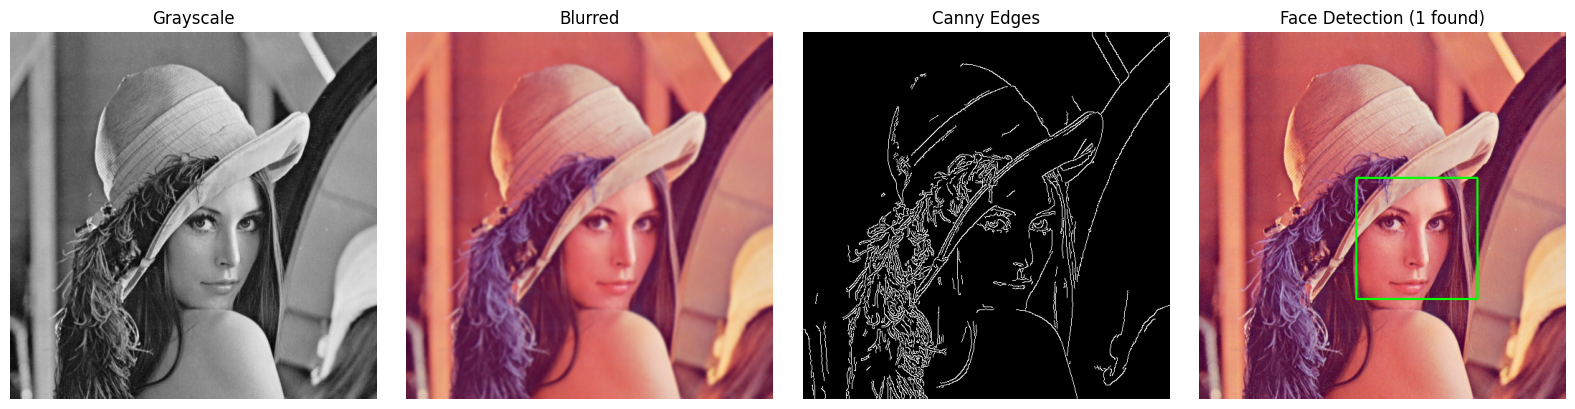

In [5]:
# Demo: download a sample image and run the OpenCV pipeline on it
!wget -q -O /content/sample.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

img = cv2.imread("/content/sample.jpg")
gray   = to_grayscale(img)
small  = resize_image(img, width=250)
blur   = apply_blur(img, 7)
edges  = canny_edges(img)
boxed, faces = detect_faces(img)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Grayscale", "Blurred", "Canny Edges", f"Face Detection ({len(faces)} found)"]
imgs = [gray, cv2.cvtColor(blur, cv2.COLOR_BGR2RGB), edges, cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)]
for ax, im, t in zip(axs, imgs, titles):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()


### A2. Product Image Classification
Transfer learning with **MobileNetV2** on CIFAR-10 as a stand-in retail product-category dataset
(swap in your own Kaggle "Retail Product Checkout Dataset" the same way — just replace the data loader).


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
# NOTE: swap class_names + data loader with your real 5-class retail set
# (shoes, bags, electronics, clothing, groceries) when you have it.

N_TRAIN, N_TEST = 6000, 1000   # subset for a fast Colab demo
x_train, y_train = x_train[:N_TRAIN], y_train[:N_TRAIN]
x_test,  y_test  = x_test[:N_TEST],  y_test[:N_TEST]

IMG_SIZE = 96

def preprocess(x, y):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x, y

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .map(preprocess).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
            .map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE))

base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False

product_classifier = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])
product_classifier.compile(optimizer="adam",
                            loss="sparse_categorical_crossentropy",
                            metrics=["accuracy"])
product_classifier.summary()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 251s 1us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = product_classifier.fit(train_ds, validation_data=test_ds, epochs=3)

loss, acc = product_classifier.evaluate(test_ds)
print(f"✅ Product classifier test accuracy: {acc:.2%}")

product_classifier.save(f"{BASE}/models/product_classifier.h5")
with open(f"{BASE}/models/class_names.json", "w") as f:
    json.dump(class_names, f)
print("✅ Saved product_classifier.h5")


Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 283ms/step - accuracy: 0.6832 - loss: 0.9521 - val_accuracy: 0.8140 - val_loss: 0.5484
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 55s 291ms/step - accuracy: 0.8188 - loss: 0.5342 - val_accuracy: 0.8310 - val_loss: 0.4993
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 276ms/step - accuracy: 0.8432 - loss: 0.4535 - val_accuracy: 0.8350 - val_loss: 0.4718
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.8350 - loss: 0.4718


✅ Product classifier test accuracy: 83.50%
✅ Saved product_classifier.h5


{'category': 'dog', 'confidence': 0.6402183175086975}


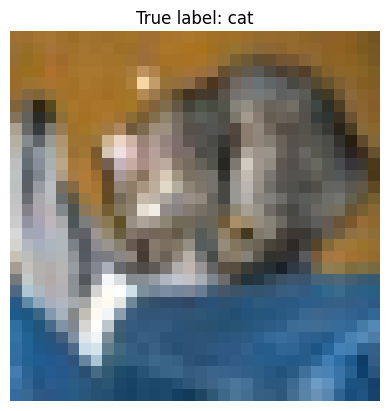

In [8]:
# Quick inference demo
def classify_product(image_bgr, model=product_classifier, classes=class_names):
    img = cv2.resize(image_bgr, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img.astype("float32"))
    pred = model.predict(np.expand_dims(img, 0), verbose=0)[0]
    idx = int(np.argmax(pred))
    return {"category": classes[idx], "confidence": float(pred[idx])}

sample = cv2.cvtColor(x_test[0], cv2.COLOR_RGB2BGR)
print(classify_product(sample))
plt.imshow(x_test[0]); plt.title(f"True label: {class_names[int(y_test[0])]}"); plt.axis("off"); plt.show()


### A3. Face Recognition — "Returning Customer" Detection
Uses OpenCV's built-in **LBPH recognizer** (no dlib compile needed — fast in Colab) on a public,
consenting-subjects face dataset (`sklearn`'s LFW subset) to simulate customer recognition + visit logging.

> **Ethics note:** in production this requires explicit customer opt-in, secure storage of encodings,
> a retention limit, and bias testing across demographic groups (see the project report, Section 6).


In [9]:
from sklearn.datasets import fetch_lfw_people
from datetime import datetime

lfw = fetch_lfw_people(min_faces_per_person=25, resize=0.6)
h, w = lfw.images.shape[1:]
customer_names = lfw.target_names
print(f"Loaded {len(lfw.images)} face images across {len(customer_names)} demo 'customers'")

# Split: first 80% of each identity -> enrollment DB, rest -> "walk-in" test images
from collections import defaultdict
by_id = defaultdict(list)
for img, label in zip(lfw.images, lfw.target):
    by_id[label].append(img)

train_imgs, train_labels, test_imgs, test_labels = [], [], [], []
for label, imgs in by_id.items():
    cut = max(1, int(len(imgs) * 0.8))
    train_imgs += imgs[:cut];  train_labels += [label] * cut
    test_imgs  += imgs[cut:]; test_labels  += [label] * (len(imgs) - cut)

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train([np.uint8(im * 255) for im in train_imgs], np.array(train_labels))
recognizer.save(f"{BASE}/models/face_recognizer.yml")

face_db_meta = {"names": customer_names.tolist(), "created": str(datetime.now())}
with open(f"{BASE}/models/face_db.pkl", "wb") as f:
    pickle.dump(face_db_meta, f)
print("✅ Trained + saved LBPH face recognizer (face_db.pkl + face_recognizer.yml)")


Loaded 2588 face images across 42 demo 'customers'
✅ Trained + saved LBPH face recognizer (face_db.pkl + face_recognizer.yml)


{'customer': 'unknown', 'status': 'new_visitor', 'confidence_distance': 104.62, 'timestamp': '2026-08-02 17:30:57.065967'}


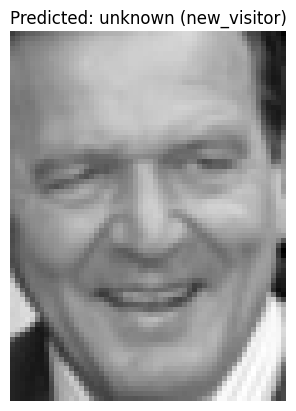

In [10]:
visit_log = []

def recognize_face(face_img_gray, threshold=70):
    face_img = np.uint8(face_img_gray * 255) if face_img_gray.max() <= 1.0 else face_img_gray
    label, confidence = recognizer.predict(face_img)   # lower confidence = more similar (LBPH)
    is_known = confidence < threshold
    result = {
        "customer": customer_names[label] if is_known else "unknown",
        "status": "returning_customer" if is_known else "new_visitor",
        "confidence_distance": round(float(confidence), 2),
        "timestamp": str(datetime.now()),
    }
    visit_log.append(result)
    return result

# Demo on a held-out 'walk-in' image
idx = 0
result = recognize_face(test_imgs[idx])
print(result)
plt.imshow(test_imgs[idx], cmap="gray")
plt.title(f"Predicted: {result['customer']} ({result['status']})"); plt.axis("off"); plt.show()


## Module B — Natural Language Processing

### B1. Text Preprocessing
Lowercasing, punctuation removal, stopword removal, and lemmatization — applied to a small
retail-reviews dataset (swap in the Kaggle "Women's E-Commerce Clothing Reviews" CSV the same way).


In [11]:
import nltk, re, string
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

# --- demo retail reviews dataset (swap with your Kaggle CSV: pd.read_csv(...)) ---
reviews = [
    ("The delivery was super fast and the packaging was excellent!", "positive"),
    ("Terrible quality, the fabric tore on the first wash.", "negative"),
    ("Absolutely love this product, will buy again for sure.", "positive"),
    ("Customer support never responded to my emails.", "negative"),
    ("Great value for the price, works exactly as described.", "positive"),
    ("The size chart was completely wrong, had to return it.", "negative"),
    ("Fast shipping and the item matched the photos perfectly.", "positive"),
    ("Very disappointed, item arrived damaged.", "negative"),
    ("Good quality material, comfortable and stylish.", "positive"),
    ("Waste of money, broke within a week.", "negative"),
    ("Exceeded my expectations, super happy with this purchase.", "positive"),
    ("The color faded after just one wash, not durable at all.", "negative"),
    ("Excellent customer service, resolved my issue quickly.", "positive"),
    ("Product description was misleading, very unhappy.", "negative"),
    ("Perfect fit and lovely design, highly recommend.", "positive"),
    ("Arrived late and the box was crushed.", "negative"),
    ("Amazing product, exactly what I needed.", "positive"),
    ("Poor stitching, fell apart after two uses.", "negative"),
    ("Really impressed with the build quality.", "positive"),
    ("Overpriced for what you actually get.", "negative"),
]
print("Sample cleaned review:")
print(" raw   ->", reviews[0][0])
print(" clean ->", clean_text(reviews[0][0]))


Sample cleaned review:
 raw   -> The delivery was super fast and the packaging was excellent!
 clean -> delivery super fast packaging excellent


### B2. Sentiment Analysis — TF-IDF + Logistic Regression

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

texts = [clean_text(t) for t, _ in reviews]
labels = [l for _, l in reviews]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

sentiment_model = LogisticRegression(max_iter=1000)
sentiment_model.fit(X_train_vec, y_train)

preds = sentiment_model.predict(X_test_vec)
print(classification_report(y_test, preds))

joblib.dump(sentiment_model, f"{BASE}/models/sentiment_model.pkl")
joblib.dump(vectorizer, f"{BASE}/models/vectorizer.pkl")
print("✅ Saved sentiment_model.pkl + vectorizer.pkl")


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5

✅ Saved sentiment_model.pkl + vectorizer.pkl


In [13]:
def analyze_sentiment(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    pred = sentiment_model.predict(vec)[0]
    proba = sentiment_model.predict_proba(vec).max()
    return {"sentiment": pred, "confidence": round(float(proba), 3)}

print(analyze_sentiment("This is the best purchase I've made all year!"))
print(analyze_sentiment("Really bad experience, would not recommend to anyone."))


{'sentiment': np.str_('positive'), 'confidence': 0.569}
{'sentiment': np.str_('positive'), 'confidence': 0.578}


### B3. FAQ Chatbot — Rule-Based + ML Intent Classification
`intents.json` holds sample FAQs (order status, returns, store hours, etc.). A TF-IDF + classifier
handles intent matching, with a rule-based keyword fallback.


In [14]:
intents = {
    "greeting": {
        "examples": ["hi", "hello", "hey there", "good morning", "is anyone there"],
        "responses": ["Hello! Welcome to our store. How can I help you today?"]
    },
    "order_status": {
        "examples": ["where is my order", "track my order", "order status", "has my package shipped"],
        "responses": ["You can track your order in the 'My Orders' section using your order ID."]
    },
    "return_policy": {
        "examples": ["what is your return policy", "can I return this", "how do refunds work", "exchange item"],
        "responses": ["Items can be returned within 30 days of delivery for a full refund."]
    },
    "store_hours": {
        "examples": ["what are your store hours", "when do you open", "closing time", "are you open today"],
        "responses": ["Our stores are open from 10 AM to 9 PM, Monday through Sunday."]
    },
    "payment_methods": {
        "examples": ["what payment methods do you accept", "can I pay with card", "do you accept cash on delivery"],
        "responses": ["We accept credit/debit cards, UPI, net banking, and cash on delivery."]
    },
    "goodbye": {
        "examples": ["bye", "goodbye", "see you later", "thanks, that's all"],
        "responses": ["Thanks for chatting with us! Have a great day."]
    },
}
with open(f"{BASE}/data/intents.json", "w") as f:
    json.dump(intents, f, indent=2)

X_intent, y_intent = [], []
for tag, data in intents.items():
    for ex in data["examples"]:
        X_intent.append(clean_text(ex))
        y_intent.append(tag)

intent_vectorizer = TfidfVectorizer()
X_intent_vec = intent_vectorizer.fit_transform(X_intent)

intent_classifier = LogisticRegression(max_iter=1000)
intent_classifier.fit(X_intent_vec, y_intent)

joblib.dump(intent_classifier, f"{BASE}/models/chatbot_model.pkl")
joblib.dump(intent_vectorizer, f"{BASE}/models/chatbot_vectorizer.pkl")
print("✅ Saved chatbot_model.pkl + intents.json")


✅ Saved chatbot_model.pkl + intents.json


In [15]:
import random

RULE_KEYWORDS = {
    "order_status": ["track", "order", "shipment", "package"],
    "return_policy": ["return", "refund", "exchange"],
    "store_hours": ["hours", "open", "close", "timing"],
    "payment_methods": ["payment", "pay", "card", "upi", "cod"],
}

def rule_based_fallback(text):
    text = text.lower()
    for tag, keywords in RULE_KEYWORDS.items():
        if any(k in text for k in keywords):
            return tag
    return None

def chatbot_reply(message, confidence_threshold=0.35):
    clean = clean_text(message)
    vec = intent_vectorizer.transform([clean])
    proba = intent_classifier.predict_proba(vec)[0]
    idx = int(np.argmax(proba))
    tag, confidence = intent_classifier.classes_[idx], proba[idx]

    if confidence < confidence_threshold:
        fallback_tag = rule_based_fallback(message)
        tag = fallback_tag if fallback_tag else "unknown"

    if tag == "unknown":
        reply = "Sorry, I didn't quite get that. Could you rephrase, or ask about orders, returns, hours, or payments?"
    else:
        reply = random.choice(intents[tag]["responses"])

    return {"intent": tag, "confidence": round(float(confidence), 3), "reply": reply}

for msg in ["Hi there!", "Where's my package?", "Can I return my shoes?", "asdkjaskdj random text"]:
    print(msg, "->", chatbot_reply(msg))


Hi there! -> {'intent': np.str_('greeting'), 'confidence': 0.374, 'reply': 'Hello! Welcome to our store. How can I help you today?'}
Where's my package? -> {'intent': 'order_status', 'confidence': 0.244, 'reply': "You can track your order in the 'My Orders' section using your order ID."}
Can I return my shoes? -> {'intent': np.str_('return_policy'), 'confidence': 0.397, 'reply': 'Items can be returned within 30 days of delivery for a full refund.'}
asdkjaskdj random text -> {'intent': 'unknown', 'confidence': 0.22, 'reply': "Sorry, I didn't quite get that. Could you rephrase, or ask about orders, returns, hours, or payments?"}


## Module C — Unified Pipeline & Deployment

### C1–C2. Unified Pipeline + Serialization
Wraps every model behind one `pipeline.py` object that loads all artifacts once — exactly what
the FastAPI layer below imports.


In [16]:
pipeline_code = '''
import joblib, pickle, json, re, string, random
import numpy as np
import cv2
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

class SmartRetailPipeline:
    def __init__(self, model_dir="models", data_dir="data"):
        self.product_classifier = tf.keras.models.load_model(f"{model_dir}/product_classifier.h5")
        self.class_names = json.load(open(f"{model_dir}/class_names.json"))

        self.face_recognizer = cv2.face.LBPHFaceRecognizer_create()
        self.face_recognizer.read(f"{model_dir}/face_recognizer.yml")
        self.face_db_meta = pickle.load(open(f"{model_dir}/face_db.pkl", "rb"))

        self.sentiment_model = joblib.load(f"{model_dir}/sentiment_model.pkl")
        self.vectorizer = joblib.load(f"{model_dir}/vectorizer.pkl")

        self.intent_classifier = joblib.load(f"{model_dir}/chatbot_model.pkl")
        self.intent_vectorizer = joblib.load(f"{model_dir}/chatbot_vectorizer.pkl")
        self.intents = json.load(open(f"{data_dir}/intents.json"))

        self.IMG_SIZE = 96
        self.visit_log = []

    def classify_product(self, image_bgr):
        img = cv2.resize(image_bgr, (self.IMG_SIZE, self.IMG_SIZE))
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img.astype("float32"))
        pred = self.product_classifier.predict(np.expand_dims(img, 0), verbose=0)[0]
        idx = int(np.argmax(pred))
        return {"category": self.class_names[idx], "confidence": float(pred[idx])}

    def recognize_face(self, face_gray, threshold=70):
        label, confidence = self.face_recognizer.predict(face_gray)
        is_known = confidence < threshold
        result = {
            "customer": self.face_db_meta["names"][label] if is_known else "unknown",
            "status": "returning_customer" if is_known else "new_visitor",
            "confidence_distance": round(float(confidence), 2),
        }
        self.visit_log.append(result)
        return result

    def analyze_sentiment(self, text):
        vec = self.vectorizer.transform([clean_text(text)])
        pred = self.sentiment_model.predict(vec)[0]
        proba = self.sentiment_model.predict_proba(vec).max()
        return {"sentiment": pred, "confidence": round(float(proba), 3)}

    def chatbot_reply(self, message, threshold=0.35):
        vec = self.intent_vectorizer.transform([clean_text(message)])
        proba = self.intent_classifier.predict_proba(vec)[0]
        idx = int(np.argmax(proba))
        tag, confidence = self.intent_classifier.classes_[idx], proba[idx]
        if confidence < threshold:
            tag = "unknown"
        reply = (random.choice(self.intents[tag]["responses"])
                 if tag != "unknown" else
                 "Sorry, could you rephrase that?")
        return {"intent": tag, "confidence": round(float(confidence), 3), "reply": reply}

    def dashboard_stats(self):
        return {
            "total_visits_logged": len(self.visit_log),
            "returning_customers": sum(1 for v in self.visit_log if v["status"] == "returning_customer"),
            "new_visitors": sum(1 for v in self.visit_log if v["status"] == "new_visitor"),
        }
'''
with open(f"{BASE}/app/pipeline.py", "w") as f:
    f.write(pipeline_code)
print("✅ pipeline.py written to", f"{BASE}/app/pipeline.py")


✅ pipeline.py written to /content/smart-retail-ai/app/pipeline.py


### C3. FastAPI Layer
Defines every endpoint from the spec (`/recognize-face`, `/classify-product`, `/analyze-sentiment`,
`/chatbot`, `/dashboard/stats`) with Pydantic validation and auto-generated Swagger docs at `/docs`.


In [17]:
main_py_code = '''
import sys, io
sys.path.append("/content/smart-retail-ai/app")
import numpy as np
import cv2
from fastapi import FastAPI, UploadFile, File, Header, HTTPException
from pydantic import BaseModel
from pipeline import SmartRetailPipeline

API_KEY = "demo-secret-key"   # replace with a real secret / env var in production

app = FastAPI(title="Smart Retail & Customer Intelligence API", version="1.0")
pipeline = SmartRetailPipeline(
    model_dir="/content/smart-retail-ai/models",
    data_dir="/content/smart-retail-ai/data",
)

def check_key(x_api_key: str = Header(None)):
    if x_api_key != API_KEY:
        raise HTTPException(status_code=401, detail="Invalid or missing API key")

class TextIn(BaseModel):
    text: str

class ChatIn(BaseModel):
    message: str

def read_image(upload_bytes):
    arr = np.frombuffer(upload_bytes, np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

@app.post("/classify-product")
async def classify_product(file: UploadFile = File(...), x_api_key: str = Header(None)):
    check_key(x_api_key)
    img = read_image(await file.read())
    return pipeline.classify_product(img)

@app.post("/recognize-face")
async def recognize_face(file: UploadFile = File(...), x_api_key: str = Header(None)):
    check_key(x_api_key)
    img = read_image(await file.read())
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return pipeline.recognize_face(gray)

@app.post("/analyze-sentiment")
async def analyze_sentiment(payload: TextIn, x_api_key: str = Header(None)):
    check_key(x_api_key)
    return pipeline.analyze_sentiment(payload.text)

@app.post("/chatbot")
async def chatbot(payload: ChatIn, x_api_key: str = Header(None)):
    check_key(x_api_key)
    return pipeline.chatbot_reply(payload.message)

@app.get("/dashboard/stats")
async def dashboard_stats(x_api_key: str = Header(None)):
    check_key(x_api_key)
    return pipeline.dashboard_stats()

@app.get("/")
async def root():
    return {"status": "Smart Retail AI API is running", "docs": "/docs"}
'''
with open(f"{BASE}/app/main.py", "w") as f:
    f.write(main_py_code)
print("✅ main.py written to", f"{BASE}/app/main.py")


✅ main.py written to /content/smart-retail-ai/app/main.py


### C4. Run the Live API in Colab
Colab can't expose ports directly, so we tunnel with **ngrok**. Get a free authtoken at
https://dashboard.ngrok.com/get-started/your-authtoken and paste it below.


In [19]:
NGROK_AUTH_TOKEN = "3HMyprwMvEkD7xl1nhzBsYxQmPB_5m5BJvPDrqAyjU7xMDwtW"  # <-- paste your free ngrok token here

import nest_asyncio, uvicorn, threading, time
from pyngrok import ngrok, conf

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN

nest_asyncio.apply()

import sys
sys.path.append(f"{BASE}/app")
import importlib, main as main_module
importlib.reload(main_module)

public_url = ngrok.connect(8000)
print("🌐 Public API URL:", public_url)
print("📖 Swagger docs:  ", str(public_url) + "/docs")

def run():
    uvicorn.run(main_module.app, host="0.0.0.0", port=8000, log_level="warning")

thread = threading.Thread(target=run, daemon=True)
thread.start()
time.sleep(3)
print("✅ API is live")


🌐 Public API URL: NgrokTunnel: "https://uptight-slashed-dirtiness.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger docs:   NgrokTunnel: "https://uptight-slashed-dirtiness.ngrok-free.dev" -> "http://localhost:8000"/docs
✅ API is live


In [22]:
# Quick smoke test against the live API (run after the cell above)
import requests

headers = {"x-api-key": "demo-secret-key"}
base_url = public_url.public_url

r = requests.post(f"{base_url}/analyze-sentiment", json={"text": "Absolutely loved this order!"}, headers=headers)
print("Sentiment:", r.json())

r = requests.post(f"{base_url}/chatbot", json={"message": "What's your return policy?"}, headers=headers)
print("Chatbot:", r.json())

r = requests.get(f"{base_url}/dashboard/stats", headers=headers)
print("Dashboard:", r.json())


Sentiment: {'sentiment': 'positive', 'confidence': 0.571}
Chatbot: {'intent': 'return_policy', 'confidence': 0.397, 'reply': 'Items can be returned within 30 days of delivery for a full refund.'}
Dashboard: {'total_visits_logged': 0, 'returning_customers': 0, 'new_visitors': 0}


## Wrap-Up & Next Steps

- **Swap in real data:** replace the CIFAR-10 stand-in with your 5-class retail image set, the LFW demo
  with your consenting customer photos, and the synthetic reviews with the Kaggle e-commerce reviews CSV.
- **Dockerize:** copy `app/` + `models/` + `data/` out of Colab into the `smart-retail-ai/` folder structure
  from the project report and add the `Dockerfile` for cloud deployment (Render/Railway/Cloud Run).
- **Everything from this notebook is already saved** under `/content/smart-retail-ai/` — download the
  `models/` and `app/` folders to continue locally.


In [23]:
# Zip everything for download
import shutil
shutil.make_archive("/content/smart-retail-ai", "zip", BASE)
print("✅ Project zipped: /content/smart-retail-ai.zip — download it from the Colab file browser")


✅ Project zipped: /content/smart-retail-ai.zip — download it from the Colab file browser


In [28]:
from google.colab import files
import requests

uploaded = files.upload()  # a file picker will pop up — choose any image
filename = list(uploaded.keys())[0]

base_url = public_url.public_url
headers = {"x-api-key": "demo-secret-key"}

with open(filename, "rb") as f:
    r = requests.post(f"{base_url}/classify-product",
                       files={"file": (filename, f, "image/jpeg")},
                       headers=headers)
print("Product classification:", r.json())

with open(filename, "rb") as f:
    r = requests.post(f"{base_url}/recognize-face",
                       files={"file": (filename, f, "image/jpeg")},
                       headers=headers)
print("Face recognition:", r.json())

Saving dog-puppy-on-garden-royalty-free-image-1586966191.avif to dog-puppy-on-garden-royalty-free-image-1586966191.avif
Product classification: {'category': 'dog', 'confidence': 0.8088813424110413}
Face recognition: {'customer': 'unknown', 'status': 'new_visitor', 'confidence_distance': 148.31}
